# Isolation Forest — détecter des anomalies

## Pourquoi on a besoin d'un algorithme dédié aux anomalies ?

**La détection d'anomalies** (*outlier detection*, *anomaly detection*) est un problème très courant en data science :

- **Fraude bancaire** : repérer les transactions suspectes parmi des millions de transactions normales.
- **Maintenance prédictive** : détecter un capteur ou une machine en train de défaillir avant la panne.
- **Cybersécurité** : signaler une connexion inhabituelle qui pourrait être une attaque.
- **Contrôle qualité** : identifier les produits défectueux sur une chaîne de production.
- **Santé** : repérer une analyse biologique anormale parmi des milliers de patients.

**Le point commun de tous ces problèmes :**
1. Les anomalies sont **rares** (typiquement < 1% des données).
2. On ne sait pas toujours à l'avance à quoi ressemble une anomalie.
3. Les classes sont **extrêmement déséquilibrées** — la classification classique est inadaptée.

> **L'analogie à garder en tête :** imagine une usine qui produit des boîtes de conserve. 99,9% sont conformes, 0,1% sont défectueuses (trop lourdes, trop légères, étiquette mal placée...). Si tu entraînes un classifieur classique sur ces données, il apprendra surtout à dire *« c'est conforme »* (puisque c'est presque toujours vrai). Tu as besoin d'un **outil spécifique** qui cherche activement ce qui **« ne ressemble pas au reste »**, sans avoir besoin d'exemples d'anomalies pour s'entraîner.

C'est exactement ce que fait **Isolation Forest**.

## Comment fonctionne Isolation Forest ?

[`IsolationForest`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html) est un **ensemble d'arbres de décision** conçus pour **« isoler » les anomalies très tôt** dans la hiérarchie de chaque arbre.

### L'idée clé

**Pour séparer un point du reste, on fait des coupes aléatoires dans l'espace.** Chaque arbre choisit au hasard :
1. une **variable** ;
2. un **seuil** entre le min et le max de cette variable ;

...et découpe les données en deux groupes. Puis il recommence récursivement jusqu'à ce que chaque point soit isolé dans une cellule à lui tout seul.

### Pourquoi ça marche pour les anomalies ?

> **L'intuition centrale :** un point « normal » est entouré de nombreux autres points similaires. Il faut **beaucoup de coupes aléatoires** pour le séparer de ses voisins. À l'inverse, un point **atypique** (valeur extrême, position isolée) sera **isolé rapidement** — parfois en 2 ou 3 coupes seulement, parce qu'il est déjà loin de tout le monde.
>
> **Autrement dit :** la **« profondeur »** à laquelle un point est isolé dans l'arbre est une **mesure de sa normalité**. Peu profond = anormal. Très profond = normal.

### Le score d'anomalie

On entraîne **plusieurs arbres** (une « forêt ») et on moyenne la profondeur d'isolation pour chaque point. Les points isolés **systématiquement tôt** dans une majorité d'arbres obtiennent le **score d'anomalie le plus élevé**.

![Principe](../../images/Principes-Algo.gif)

![isolation forest](../../images/isolation_forrest.png)

### Forces d'Isolation Forest

- ✅ **Non-supervisé** : pas besoin d'exemples d'anomalies pour s'entraîner. Il apprend juste à partir de données « normales ».
- ✅ **Efficace en haute dimension** (contrairement aux méthodes basées sur la densité comme DBScan).
- ✅ **Scalable** : complexité **linéaire** en nombre d'échantillons.
- ✅ **Simple à utiliser** : très peu d'hyperparamètres à régler (essentiellement `contamination`, la proportion estimée d'anomalies).
- ✅ **Robuste** : pas besoin de normaliser les données (on coupe par seuils, comme les arbres de décision classiques).

### Limites à connaître

- ⚠️ **Ne marche pas sur des anomalies « complexes »** qui ne sont pas isolables par coupes axiales (par exemple une anomalie entourée d'un cluster normal).
- ⚠️ **L'hyperparamètre `contamination`** doit être estimé à l'avance — s'il est faux, le modèle surestimera ou sous-estimera le nombre d'anomalies.
- ⚠️ **Moins performant que des modèles supervisés** quand on *a* des exemples d'anomalies labellisés (dans ce cas, on préfère un classifieur avec `class_weight='balanced'` ou du sur-échantillonnage).

## Exemple

### Génération des données

**Pour illustrer Isolation Forest**, on construit un **dataset synthétique** en 2D qui contient :

- **Un cluster sphérique** de points « normaux » (tirés selon une loi normale centrée) → label `1`.
- **Un cluster ovale** de points « normaux » (autre loi normale avec une forme allongée) → label `1`.
- **Des anomalies** tirées uniformément dans tout l'espace → label `-1`.

> **Note sur les labels** : Isolation Forest (comme les autres détecteurs de scikit-learn) utilise la convention `+1` pour les points normaux et `-1` pour les anomalies. C'est différent des classifieurs classiques (qui utilisent 0 et 1). Un piège classique quand on compare des métriques entre les deux !

In [1]:
import numpy as np

from sklearn.model_selection import train_test_split

n_samples, n_outliers = 120, 40
rng = np.random.RandomState(0)
covariance = np.array([[0.5, -0.1], [0.7, 0.4]])
cluster_1 = 0.4 * rng.randn(n_samples, 2) @ covariance + np.array([2, 2])  # oval
cluster_2 = 0.3 * rng.randn(n_samples, 2) + np.array([-2, -2])  # spherical
outliers = rng.uniform(low=-4, high=4, size=(n_outliers, 2))

X = np.concatenate([cluster_1, cluster_2, outliers])
y = np.concatenate(
    [np.ones((2 * n_samples), dtype=int), -np.ones((n_outliers), dtype=int)]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

### Visualisation

**Toujours regarder ses données avant d'entraîner un modèle.** On utilise un scatter plot 2D, coloré par label, pour voir où sont les deux clusters normaux et où se dispersent les anomalies.

> **À observer :** les anomalies (label `-1`) sont visuellement « loin » des clusters normaux. Un Isolation Forest devrait les repérer facilement.

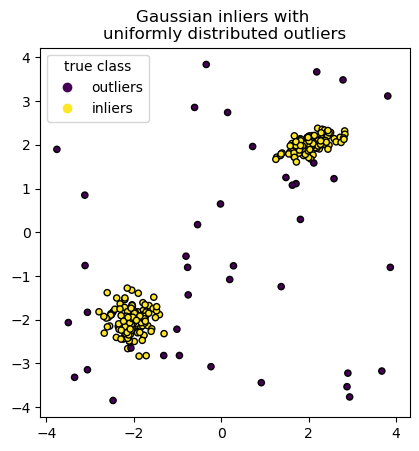

In [2]:
import matplotlib.pyplot as plt

scatter = plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor="k")
handles, labels = scatter.legend_elements()
plt.axis("square")
plt.legend(handles=handles, labels=["outliers", "inliers"], title="true class")
plt.title("Gaussian inliers with \nuniformly distributed outliers")
plt.show()

### Apprentissage

**L'entraînement d'un Isolation Forest se fait avec `.fit(X)` — sans passer de labels.** C'est un algorithme **non-supervisé** : il apprend juste à identifier ce qui « ne ressemble pas au reste » à partir des données brutes.

Les hyperparamètres principaux :

- **`max_samples`** : nombre d'échantillons utilisés pour construire chaque arbre. 100 est une valeur classique pour de gros datasets.
- **`contamination`** : proportion estimée d'anomalies dans les données. Par défaut `'auto'`, mais c'est souvent utile de la fixer à la main (par exemple `0.1` si on estime 10% d'anomalies).
- **`n_estimators`** : nombre d'arbres dans la forêt (100 par défaut).

In [3]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(max_samples=100, random_state=0)
clf.fit(X_train)

IsolationForest(max_samples=100, random_state=0)

### Frontières de décision

**Pour visualiser ce que le modèle a appris**, on dessine ses **frontières de décision** : pour chaque point de l'espace 2D, on demande au modèle *« est-ce une anomalie ? »* et on colorie le résultat. On utilise [`DecisionBoundaryDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.DecisionBoundaryDisplay.html).

> **Lecture attendue :** la zone colorée « anomalie » devrait englober tout ce qui est loin des deux clusters normaux. On voit visuellement si l'algorithme a bien compris la structure des données.

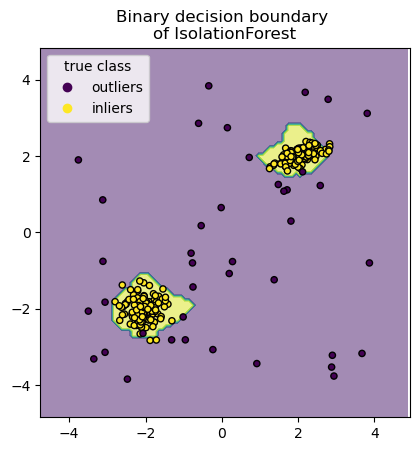

In [4]:
import matplotlib.pyplot as plt

from sklearn.inspection import DecisionBoundaryDisplay

disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    response_method="predict",
    alpha=0.5,
)
disp.ax_.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor="k")
disp.ax_.set_title("Binary decision boundary \nof IsolationForest")
plt.axis("square")
plt.legend(handles=handles, labels=["outliers", "inliers"], title="true class")
plt.show()

### Longueur des chemins de décision — le score continu

**Au lieu d'un verdict binaire** (« anomalie » / « pas anomalie »), Isolation Forest peut donner un **score continu** de « normalité ». En utilisant `response_method="decision_function"`, on obtient une mesure qui reflète **à quel point un point est « normal »** :

- **Score élevé** (proche de 0 ou positif) → le point est au cœur d'un cluster normal.
- **Score faible** (négatif) → le point est une anomalie probable.

> **🎯 Pourquoi le score continu est utile en pratique ?**
>
> En production, on ne veut pas juste un verdict binaire — on veut **prioriser** les cas à investiguer. Sur un système anti-fraude, on peut avoir 10 000 transactions « suspectes » par jour. On ne peut pas tout vérifier manuellement. **Trier par score** permet à l'équipe de fraude de **commencer par les plus louches** et de remonter vers les moins louches jusqu'à épuisement du temps disponible.
>
> C'est aussi ce qui permet de **tracer une courbe ROC** ou **précision-rappel** pour évaluer le modèle : il faut un score continu pour pouvoir faire varier le seuil.

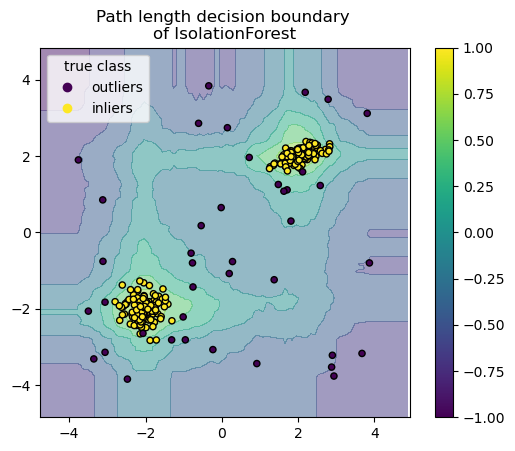

In [5]:
disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    response_method="decision_function",
    alpha=0.5,
)
disp.ax_.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor="k")
disp.ax_.set_title("Path length decision boundary \nof IsolationForest")
plt.axis("square")
plt.legend(handles=handles, labels=["outliers", "inliers"], title="true class")
plt.colorbar(disp.ax_.collections[1])
plt.show()

## Autres algorithmes de détection d'anomalies

Scikit-learn propose [**plusieurs autres méthodes**](https://scikit-learn.org/stable/modules/outlier_detection.html) de détection d'anomalies. Voici les principales familles :

### Méthodes basées sur la densité

**L'idée :** un point est anormal s'il se trouve dans une zone **peu dense** — c'est-à-dire s'il a peu de voisins proches.

- **[DBScan](https://scikit-learn.org/stable/modules/clustering.html#dbscan)** : algorithme de clustering qui **étiquette en outliers** les points qui ne sont dans aucun cluster dense. Il trouve **lui-même** le nombre de clusters (contrairement à K-Means), ce qui en fait un bon choix si on ne sait pas à quoi s'attendre.
- **LOF (*Local Outlier Factor*)** : calcule pour chaque point le ratio entre sa densité locale et celle de ses voisins. Un point dans une zone beaucoup moins dense que ses voisins est suspect.

> **Limite de ces méthodes :** elles **ne marchent pas bien en haute dimension** (la fameuse *curse of dimensionality*). En dimension > 20-30, toutes les distances se ressemblent et la notion de « densité locale » perd son sens.

### Méthodes basées sur la reconstruction

**L'idée :** on apprend un modèle qui **compresse** puis **reconstruit** les données. Les points qui ne peuvent pas être bien reconstruits sont anormaux.

- **[PCA + reconstruction](https://www.atmosera.com/blog/pca-based-anomaly-detection/)** : on projette les données dans un espace réduit (ex : 10 composantes principales), puis on les « déprojette ». Un point reconstruit avec une grosse erreur est suspect.
- **Autoencodeurs** (deep learning) : même principe mais avec un réseau de neurones. Plus puissant mais demande plus de données et de calcul.

### Méthodes à « classe unique »

**L'idée :** au lieu de détecter des anomalies comme *« ce qui ne ressemble pas au reste »*, on apprend la **frontière** autour de ce qui est normal, et tout ce qui est dehors est anomalie.

- **One-Class SVM** : un SVM qui apprend une « bulle » autour des données normales. Tout ce qui sort de la bulle est une anomalie.
- **Elliptic Envelope** : variante qui suppose que les données normales suivent une distribution gaussienne multivariée et trace une ellipse autour.

### Le tableau de choix

| Méthode | Bon en haute dim ? | Interprétable ? | Cas d'usage typique |
|---|:---:|:---:|---|
| **Isolation Forest** | ✅ | Moyen | **Le choix par défaut**, très généraliste |
| **DBScan** | ❌ | ✅ (clusters visibles) | Clustering + anomalies géographiques |
| **LOF** | ❌ | ✅ | Petits datasets avec structure locale |
| **PCA reconstruction** | ✅ | Moyen | Données linéairement compressibles |
| **Autoencodeurs** | ✅ | ❌ | Gros datasets, structures complexes |
| **One-Class SVM** | Moyen | ❌ | Petits datasets, frontière nette |
| **Elliptic Envelope** | ❌ | ✅ | Données gaussiennes |

## 🎯 Pour résumer — Isolation Forest en pratique

### Quand l'utiliser

- ✅ **Détection de fraude** (bancaire, assurance) : énorme volume de données, très peu d'anomalies connues.
- ✅ **Maintenance prédictive** : détecter un équipement qui « sort de son comportement normal ».
- ✅ **Cybersécurité** : repérer des connexions, requêtes ou volumes de trafic inhabituels.
- ✅ **Contrôle qualité industriel** : identifier les pièces défectueuses dès la production.
- ✅ **Détection de bugs en prod** : un log de comportement applicatif qui diffère du profil normal.

### Quand ne pas l'utiliser

- ⚠️ **Quand tu as des labels d'anomalies** → utilise plutôt un classifieur supervisé (`RandomForest`, `XGBoost`) avec `class_weight='balanced'`. Un modèle supervisé bat presque toujours un détecteur non supervisé quand tu as les labels.
- ⚠️ **Quand les anomalies sont « contextuelles »** (une valeur peut être normale dans un contexte et anormale dans un autre) → Isolation Forest n'a pas de notion de contexte, il faut ajouter explicitement les features contextuelles.
- ⚠️ **Pour des séries temporelles** → utilise plutôt des méthodes dédiées (détection de ruptures, Prophet, modèles de séries temporelles avec résidus).

### Les pièges à éviter

- ⚠️ **Fixer `contamination` au hasard** → un mauvais choix fausse tout. Estime-le à partir de ton contexte métier ou par essais successifs.
- ⚠️ **Oublier que les labels sont `+1` / `-1`** (et non 0 / 1 comme en classification classique). Un bug classique quand on calcule des métriques.
- ⚠️ **Évaluer avec de l'accuracy** → sur 99% de normaux, dire toujours « normal » donne 99% d'accuracy. **Toujours** utiliser précision, rappel, F1 ou PR-AUC sur la classe « anomalie ».
- ⚠️ **Ne pas visualiser le score avant de décider** → souvent, un simple histogramme des scores révèle un seuil naturel (une vallée dans la distribution) bien meilleur que le seuil par défaut.

### Le geste en code

```python
from sklearn.ensemble import IsolationForest

# On estime 1% d'anomalies dans les données
clf = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)
clf.fit(X_train)

# Prédiction binaire : +1 = normal, -1 = anomalie
predictions = clf.predict(X_test)

# Score continu : plus c'est bas, plus c'est anormal
scores = clf.decision_function(X_test)

# Trier du plus suspect au moins suspect
suspicious_idx = scores.argsort()[:50]  # les 50 plus suspects
```

### Le mot de la fin

> **Isolation Forest est le détecteur d'anomalies « couteau suisse » de scikit-learn.** Il est simple, rapide, efficace en haute dimension, et demande très peu de tuning. Pour 80% des cas de détection d'anomalies non supervisées, c'est le **premier algo à essayer**. Et si tu as des labels d'anomalies, n'oublie pas de comparer avec un classifieur supervisé — tu pourrais être surpris par l'écart.